# Phase 1 — Exploration et vérification de la randomisation

**Question de cette phase** : avant de mesurer quoi que ce soit, peut-on faire confiance à l'expérience ?
Si l'assignation aux groupes est vraiment aléatoire, les trois groupes sont statistiquement identiques *avant* l'envoi des e-mails — et toute différence observée *après* est attribuable à l'e-mail (effet **causal**). C'est ce qu'on vérifie ici.

## 1. Charger les données

`pd.read_csv` lit le fichier en `DataFrame` : une ligne par client, une colonne par variable.

In [1]:
import pandas as pd

df = pd.read_csv("../data/hillstrom.csv")
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 2. Structure : dimensions, types, valeurs manquantes

- `shape` : (nombre de lignes, nombre de colonnes).
- `dtypes` : `int64`/`float64` = numérique, `str` = texte (catégoriel ; `object` dans les versions de pandas antérieures à 3.0).
- `isna().sum()` : nombre de valeurs manquantes par colonne.

In [2]:
print(df.shape)
pd.DataFrame({"type": df.dtypes, "manquants": df.isna().sum(), "valeurs distinctes": df.nunique()})

(64000, 12)


,type,manquants,valeurs distinctes
recency,int64,0,12
history_segment,str,0,7
history,float64,0,34833
mens,int64,0,2
womens,int64,0,2
zip_code,str,0,3
newbie,int64,0,2
channel,str,0,3
segment,str,0,3
visit,int64,0,2


## 3. Taille des groupes de traitement

`segment` est la variable de **traitement**. Le protocole annonce une répartition 1/3 – 1/3 – 1/3 : on vérifie d'abord à l'œil.

In [3]:
df["segment"].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

## 4. Test du χ² d'ajustement : y a-t-il un *sample ratio mismatch* ?

**Idée** : on compare les effectifs **observés** aux effectifs **attendus** si l'assignation suivait exactement le protocole (1/3 chacun, soit 64 000 / 3 ≈ 21 333 par groupe).

**Statistique** : χ² = Σ (observé − attendu)² / attendu. Elle vaut 0 si tout colle parfaitement et grandit avec les écarts.

**Hypothèse nulle H₀** : la vraie répartition est 1/3 – 1/3 – 1/3, et les écarts observés ne viennent que du hasard du tirage.

**p-value** : la probabilité d'obtenir un χ² au moins aussi grand que celui observé *si H₀ est vraie*. Une p-value très petite (en pratique, pour un contrôle de *sample ratio mismatch*, on prend souvent un seuil strict comme 0,001) signale un problème dans l'assignation : bug de tirage, clients perdus dans un groupe, etc. Dans ce cas, aucune conclusion causale ne serait fiable.

Avec 3 groupes, on a 3 − 1 = **2 degrés de liberté** (une fois deux effectifs fixés, le troisième est imposé par le total).

In [4]:
from scipy import stats

observes = df["segment"].value_counts()
attendus = [len(df) / 3] * 3

chi2, p_value = stats.chisquare(f_obs=observes, f_exp=attendus)

print(pd.DataFrame({"observé": observes, "attendu": attendus, "écart": observes - attendus}).round(1))
print()
print(f"χ² = {chi2:.3f}   (2 degrés de liberté)")
print(f"p-value = {p_value:.3f}")

               observé  attendu  écart
segment                               
Womens E-Mail    21387  21333.3   53.7
Mens E-Mail      21307  21333.3  -26.3
No E-Mail        21306  21333.3  -27.3

χ² = 0.203   (2 degrés de liberté)
p-value = 0.904


**Interprétation** : χ² ≈ 0,2 et p ≈ 0,90. Si l'assignation était parfaitement 1/3 – 1/3 – 1/3, on observerait des écarts au moins aussi grands que ceux-ci dans environ 90 % des expériences. Le plus gros écart (+54 clients pour l'e-mail Femmes) représente 0,25 % de l'effectif attendu, ce qui relève du bruit normal d'un tirage aléatoire.

➡️ **Aucun *sample ratio mismatch*** : la répartition est compatible avec le protocole annoncé.

⚠️ Une p-value élevée ne *prouve* pas que H₀ est vraie ; elle dit seulement que les données ne fournissent aucune raison d'en douter. Ce test ne vérifie que les **tailles** de groupes, pas leur **composition** : c'est l'objet de l'étape suivante.

## 5. Équilibre des covariables : test du χ² d'indépendance

Le test précédent portait sur la **taille** des groupes. On vérifie maintenant leur **composition** : les clients ont-ils les mêmes caractéristiques *avant* l'envoi (des **covariables pré-traitement**) d'un groupe à l'autre ?

**Le test du χ² d'indépendance** part d'un **tableau de contingence** (groupe × modalité de la variable) :
- **H₀** : la variable est indépendante du groupe. La proportion d'Urban, par exemple, est la même dans les 3 groupes.
- **Effectifs attendus sous H₀** : (total de la ligne × total de la colonne) / total général, c'est-à-dire ce qu'on observerait si chaque groupe reproduisait exactement la répartition globale.
- Même statistique qu'avant, Σ (observé − attendu)² / attendu, sommée sur toutes les cases. **Degrés de liberté** = (lignes − 1) × (colonnes − 1).

On commence par un exemple détaillé sur `zip_code`.

In [5]:
contingence = pd.crosstab(df["segment"], df["zip_code"])
print("Effectifs observés :")
print(contingence)
print()
print("Proportions par groupe (chaque ligne somme à 100 %) :")
print((pd.crosstab(df["segment"], df["zip_code"], normalize="index") * 100).round(2))

Effectifs observés :
zip_code       Rural  Surburban  Urban
segment                               
Mens E-Mail     3243       9501   8563
No E-Mail       3139       9625   8542
Womens E-Mail   3181       9650   8556

Proportions par groupe (chaque ligne somme à 100 %) :
zip_code       Rural  Surburban  Urban
segment                               
Mens E-Mail    15.22      44.59  40.19
No E-Mail      14.73      45.18  40.09
Womens E-Mail  14.87      45.12  40.01


In [6]:
chi2, p_value, ddl, attendus = stats.chi2_contingency(contingence)

print("Effectifs attendus sous H₀ :")
print(pd.DataFrame(attendus, index=contingence.index, columns=contingence.columns).round(1))
print()
print(f"χ² = {chi2:.3f}   ddl = {ddl}   p-value = {p_value:.3f}")

Effectifs attendus sous H₀ :
zip_code        Rural  Surburban   Urban
segment                                 
Mens E-Mail    3183.7     9580.2  8543.1
No E-Mail      3183.6     9579.7  8542.7
Womens E-Mail  3195.7     9616.1  8575.2

χ² = 2.872   ddl = 4   p-value = 0.579


### Toutes les covariables catégorielles

On applique le même test à chaque variable catégorielle ou binaire. `recency` (12 valeurs, de 1 à 12 mois) est traitée ici comme une variable catégorielle. `history` est continue, avec ~35 000 valeurs distinctes : on la couvre via sa version découpée en tranches, `history_segment`, et elle sera traitée directement par les différences standardisées à l'étape suivante.

In [7]:
covariables = ["recency", "history_segment", "mens", "womens", "zip_code", "newbie", "channel"]

resultats = []
for var in covariables:
    chi2, p_value, ddl, _ = stats.chi2_contingency(pd.crosstab(df["segment"], df[var]))
    resultats.append({"variable": var, "χ²": round(chi2, 2), "ddl": ddl, "p-value": round(p_value, 3)})

pd.DataFrame(resultats).set_index("variable")

,χ²,ddl,p-value
variable,,,
recency,13.38,22,0.922
history_segment,13.15,12,0.358
mens,0.80,2,0.672
womens,0.63,2,0.729
zip_code,2.87,4,0.579
newbie,0.14,2,0.934
channel,3.63,4,0.458


**Interprétation** : aucune covariable n'est significativement liée au groupe. La plus petite p-value vaut 0,358, loin de 0,05.

**Point de méthode : les comparaisons multiples.** On a fait 7 tests. Même si tout est parfaitement équilibré, chaque test a 5 % de chances de passer sous 0,05 par hasard, donc on s'attend à environ 7 × 0,05 ≈ 0,35 « faux positif ». Si une variable était sortie à p = 0,04, cela n'aurait pas suffi à conclure à un déséquilibre. Ici la question ne se pose même pas.

**Limite** : comme pour le test précédent, une p-value non significative ne mesure pas *l'ampleur* d'un écart. Et avec 64 000 clients, le test deviendrait au contraire significatif pour des écarts minuscules et sans conséquence pratique. D'où l'étape suivante : les **différences standardisées**, qui mesurent l'ampleur d'un déséquilibre indépendamment de la taille de l'échantillon.

## 6. Différences standardisées (SMD) et *love plot*

**Pourquoi** : une p-value mélange deux choses, l'ampleur de l'écart et la taille de l'échantillon. La **différence standardisée** ne garde que l'ampleur :

$$SMD = rac{ar{x}_{	ext{traité}} - ar{x}_{	ext{contrôle}}}{\sqrt{(s^2_{	ext{traité}} + s^2_{	ext{contrôle}})/2}}$$

C'est l'écart de moyennes exprimé en écarts-types « poolés ». Elle ne dépend pas de n. **Règle usuelle** (Austin, 2009) : |SMD| < 0,1 indique un équilibre satisfaisant.

**Variables catégorielles** : on les transforme en indicatrices 0/1 (une colonne par modalité, `pd.get_dummies`). La moyenne d'une indicatrice est une proportion, et sa variance vaut p(1 − p) : la même formule s'applique donc telle quelle.

On compare chaque groupe traité au groupe **contrôle** (`No E-Mail`), car c'est ce contraste qui servira à mesurer l'effet.

In [8]:
import numpy as np

# Matrice des covariables : numériques telles quelles, catégorielles en indicatrices
X = pd.get_dummies(df[["recency", "history", "mens", "womens", "newbie", "zip_code", "channel"]],
                   columns=["zip_code", "channel"], dtype=float)

def smd(x_traite, x_controle):
    """Différence standardisée de moyennes, avec variance poolée."""
    ecart_type_poole = np.sqrt((x_traite.var() + x_controle.var()) / 2)
    return (x_traite.mean() - x_controle.mean()) / ecart_type_poole

controle = X[df["segment"] == "No E-Mail"]
tableau_smd = pd.DataFrame({
    groupe: smd(X[df["segment"] == groupe], controle)
    for groupe in ["Mens E-Mail", "Womens E-Mail"]
})
tableau_smd.round(4)

,Mens E-Mail,Womens E-Mail
recency,0.0068,0.0052
history,0.0076,0.0065
mens,-0.0046,-0.0086
womens,0.0076,0.0049
newbie,-0.0009,0.0026
zip_code_Rural,0.0137,0.0040
zip_code_Surburban,-0.0117,-0.0011
zip_code_Urban,0.0020,-0.0018
channel_Multichannel,-0.0042,-0.0053
channel_Phone,-0.0083,0.0086


Le **love plot** représente chaque covariable sur une ligne, avec sa SMD par groupe traité. On lit d'un coup d'œil si un point sort de la bande ±0,1.

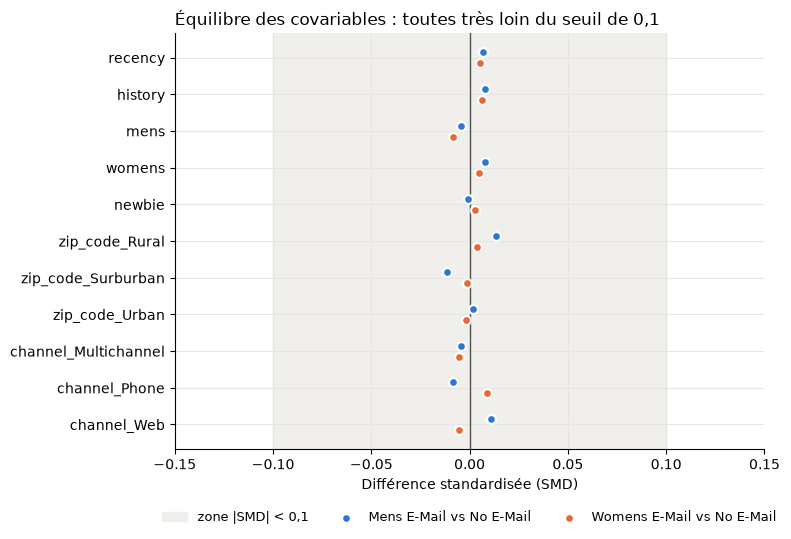

|SMD| maximale : 0.0137


In [9]:
import matplotlib.pyplot as plt

COULEURS = {"No E-Mail": "#8a8984", "Mens E-Mail": "#2a78d6", "Womens E-Mail": "#eb6834"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 10})

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(tableau_smd))
ax.axvspan(-0.1, 0.1, color="#f0efec", zorder=0, label="zone |SMD| < 0,1")
ax.axvline(0, color="#52514e", linewidth=1)
for decalage, groupe in [(-0.15, "Mens E-Mail"), (0.15, "Womens E-Mail")]:
    ax.scatter(tableau_smd[groupe], y + decalage, s=40, color=COULEURS[groupe],
               edgecolor="white", linewidth=1.5, zorder=3, label=f"{groupe} vs No E-Mail")
ax.set_yticks(y, tableau_smd.index)
ax.set_xlim(-0.15, 0.15)
ax.set_xlabel("Différence standardisée (SMD)")
ax.set_title("Équilibre des covariables : toutes très loin du seuil de 0,1", loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../docs/figures/01_love_plot.png", dpi=150)
plt.show()

print(f"|SMD| maximale : {tableau_smd.abs().max().max():.4f}")

**Interprétation** : la plus grande |SMD| est de l'ordre de 0,01, soit **dix fois sous le seuil** de 0,1. Les trois groupes sont interchangeables sur tout ce qu'on observe avant l'envoi.

**Ce que la randomisation garantit de plus** : elle équilibre aussi les variables **non observées** (motivation, revenu, goûts…) *en espérance*. C'est ce qu'aucune méthode observationnelle (appariement, régression) ne peut garantir, et c'est ce qui autorise une lecture **causale** des écarts de résultats.

## 7. Premier coup d'œil aux résultats

Les trois résultats mesurés sur les deux semaines suivant l'envoi :
- `visit` : le client a visité le site (0/1).
- `conversion` : le client a acheté (0/1).
- `spend` : montant dépensé en $ (0 si pas d'achat).

In [10]:
resume = df.groupby("segment")[["visit", "conversion", "spend"]].mean()
resume = resume.loc[["No E-Mail", "Mens E-Mail", "Womens E-Mail"]]
affichage = resume.copy()
affichage["visit"] = (affichage["visit"] * 100).round(2).astype(str) + " %"
affichage["conversion"] = (affichage["conversion"] * 100).round(3).astype(str) + " %"
affichage["spend"] = affichage["spend"].round(3).astype(str) + " $"
affichage

,visit,conversion,spend
segment,,,
No E-Mail,10.62 %,0.573 %,0.653 $
Mens E-Mail,18.28 %,1.253 %,1.423 $
Womens E-Mail,15.14 %,0.884 %,1.077 $


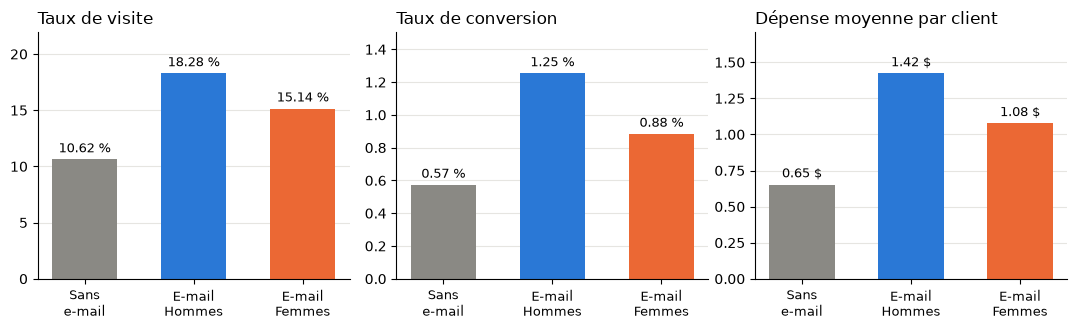

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, (col, titre, echelle, unite) in zip(axes, [("visit", "Taux de visite", 100, "%"),
                                                  ("conversion", "Taux de conversion", 100, "%"),
                                                  ("spend", "Dépense moyenne par client", 1, "$")]):
    valeurs = resume[col] * echelle
    barres = ax.bar(range(3), valeurs, color=[COULEURS[g] for g in resume.index], width=0.6)
    ax.bar_label(barres, labels=[f"{v:.2f} {unite}" for v in valeurs], padding=3, fontsize=9)
    ax.set_xticks(range(3), ["Sans\ne-mail", "E-mail\nHommes", "E-mail\nFemmes"], fontsize=9)
    ax.set_title(titre, loc="left")
    ax.set_ylim(0, valeurs.max() * 1.2)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("../docs/figures/01_resultats_par_groupe.png", dpi=150)
plt.show()

### La forme de la dépense : presque que des zéros

La moyenne de `spend` cache une distribution très particulière. C'est crucial pour le choix des tests en phase 2.

In [12]:
part_zeros = (df["spend"] == 0).mean()
acheteurs = df[df["spend"] > 0]
print(f"Clients sans achat : {part_zeros:.2%}")
print(f"Nombre d'acheteurs : {len(acheteurs)} sur {len(df)}")
print()
print("Montant chez les acheteurs, par groupe :")
acheteurs.groupby("segment")["spend"].describe().round(1)

Clients sans achat : 99.10%
Nombre d'acheteurs : 578 sur 64000

Montant chez les acheteurs, par groupe :


,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Mens E-Mail,267.0,113.5,111.7,30.0,30.0,67.0,152.7,499.0
No E-Mail,122.0,114.0,103.0,30.0,35.0,88.4,146.2,499.0
Womens E-Mail,189.0,121.9,105.8,30.0,35.2,94.7,163.8,499.0


## Conclusion de la phase 1

1. **Données propres** : 64 000 clients, aucune valeur manquante.
2. **Pas de *sample ratio mismatch*** : χ² = 0,20, p = 0,90.
3. **Covariables équilibrées** : tous les χ² d'indépendance ont p ≥ 0,36, et toutes les |SMD| sont ≈ 0,01, très loin de 0,1.
   → La randomisation a fonctionné, et les écarts de résultats peuvent être lus comme des **effets causaux** de l'e-mail.
4. **Premiers signaux** : les deux e-mails semblent augmenter visite, conversion et dépense, et l'e-mail **Hommes** paraît plus efficace que l'e-mail Femmes. Il reste à établir si ces écarts dépassent le bruit (phase 2) et si l'expérience était assez puissante pour les détecter (phase 3).
5. **Point d'attention pour la suite** : plus de 99 % des clients ne dépensent rien. La variable `spend` est **zéro-inflatée** et très asymétrique (de quelques $ à 499 $), ce qui impose des précautions statistiques (phase 2 : Welch, bootstrap) et explique pourquoi l'effet sur la dépense sera le plus difficile à mesurer précisément.